In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import os
import h5py as h5
import random
from scipy.stats import zscore
import matplotlib as mpl
from matplotlib.gridspec import GridSpec
import networkx as nx
import pandas as pd
import pickle

In [2]:
def change_font(font_size = 10, font_choice = False):
    '''
    Custom function for changing the font size in a plt plot, aesthetic purposes
    '''
    font = {'family' : 'serif',
            'weight' : 'normal', #bold
            'size'   : font_size}
    
    mpl.rc('font', **font)

In [3]:
def custom_z_score(data, baseline_window, bin_window):
    '''
    Custom function that does z-score based on control condition, and bins that data, 
    to then find average mean, standard deviation values based on condition. Then when 
    z-score rest of data, it is relative to the baseline condition.

    Inputs: 
        data: numpy 2D, shape of (neurons, data)
        baseline_window: list, first 0th index inclusive to second 0th index exclusive
        bin_window: tuple int, how long (time points) of a bin to average across the baseline_window
    '''

    n_bins = int((baseline_window[1] - baseline_window[0]) / bin_window)
    z_data = np.zeros((data.shape[0], data.shape[1]))
    
    for roiID in range(data.shape[0]):
        mean_baselines = np.zeros((n_bins))
        standard_deviation_baselines = np.zeros((n_bins))
        roi_data = data[roiID]
        
        for binID in range(n_bins):
            window0 = binID * bin_window
            mean_bin = np.mean(roi_data[window0:window0+bin_window])
            standard_deviation_bin = np.std(roi_data[window0:window0+bin_window])
            mean_baselines[binID] = mean_bin
            standard_deviation_baselines[binID] = standard_deviation_bin
        
        avg_mean_baseline = np.mean(mean_baselines)
        avg_standard_deviation_baseline = np.mean(standard_deviation_baselines)
        z_data[roiID] = (data[roiID] - avg_mean_baseline) / avg_standard_deviation_baseline
        
    return z_data

In [4]:
fish_label='20250326_fish2'
home_dir = '/Volumes/Elements/cmpk2/'
output_folder = 'output_stepC'
to_save_figs_dir = '/Users/desi/Desktop/caltech_mac/cmpk2/Regional/Figures/'

# NOTE: INCLUDE THE NAMES OF RELEVANT SCHEMATIC FILES, DICTIONARIES. DO FOR LATER.
fish_dir = os.path.join(home_dir, fish_label.split('_')[0], fish_label.split('_')[1])
output_folder_path = os.path.join(fish_dir, output_folder)

cells_fname = os.path.join(output_folder_path, 'cells0_clean.hdf5')
volume_fname = os.path.join(output_folder_path, 'volume0.hdf5')

# checking if relevant files exist 

print('home_dir path: {0}'.format(home_dir))
print('home_dir path exists: {0}'.format(os.path.isdir(home_dir)))
print('{0}'.format('-'*(len(home_dir)+len(' path: ')))) #cosmetic line

print('output_folder path: {0}'.format(output_folder_path))
print('output_folder path exists: {0}'.format(os.path.isdir(output_folder_path)))
print('{0}'.format('-'*(len(output_folder_path)+len(' path: ')))) #cosmetic line,

print('to_save_figs_dir path: {0}'.format(to_save_figs_dir))
print('to_save_figs_dir path exists: {0}'.format(os.path.isdir(to_save_figs_dir)))
print('{0}'.format('-'*(len(to_save_figs_dir)+len(' path: ')))) #cosmetic line,

home_dir path: /Volumes/Elements/cmpk2/
home_dir path exists: True
-------------------------------
output_folder path: /Volumes/Elements/cmpk2/20250326/fish2/output_stepC
output_folder path exists: True
----------------------------------------------------------
to_save_figs_dir path: /Users/desi/Desktop/caltech_mac/cmpk2/Regional/Figures/
to_save_figs_dir path exists: True
--------------------------------------------------------------


In [5]:
# fish_dir = '/Volumes/Elements/cmpk2/20250326/fish2/'


# output_folder_path = '/Volumes/Elements/cmpk2/20250326/fish2/output_stepC/'
# cells_fname = os.path.join(output_folder_path, 'cells0_clean.hdf5')
# volume_fname = os.path.join(output_folder_path, 'volume0.hdf5')




In [6]:
with h5.File(cells_fname) as cell_f:
    cell_timeseries = cell_f['cell_timeseries'][...]
    cell_timeseries_raw = cell_f['cell_timeseries_raw'][()]
    cell_x, cell_y, cell_z = cell_f['cell_x'][()], cell_f['cell_y'][()], cell_f['cell_z'][()]
    n_cells = cell_f['n'][...]
    background = cell_f['background'][...]
    print(cell_f.keys())

with h5.File(volume_fname) as volume_f: 
    volume_mean = volume_f['volume_mean'][...]

<KeysViewHDF5 ['background', 'cell_baseline', 'cell_block_id', 'cell_timeseries', 'cell_timeseries_raw', 'cell_weights', 'cell_x', 'cell_y', 'cell_z', 'n', 't', 'volume_id', 'volume_weight', 'x', 'y', 'z']>


In [7]:
baseline_window = [600, 1919]
bin_window = 120

data_minus_background = cell_timeseries_raw - background

z_data = custom_z_score(data_minus_background, baseline_window, bin_window)

In [8]:
assigned_csv_fname = os.path.join(fish_dir, 'brain', 'assigned_fish2.csv')
assigned_np_fname  = os.path.join(fish_dir, 'brain', 'assigned_unique_fish2.npy')
assigned_csv = pd.read_csv(assigned_csv_fname)
assigned_np = np.load(assigned_np_fname)

Getting the names of the regions

In [9]:
assigned_csv

,Unnamed: 0,cell_id,x,y,z,region
0,12,1,232,313,16,nucleus_isthmi.tif
1,13,1,232,313,16,superior_ventral_medulla_oblongata_(entire).tif
2,14,1,232,313,17,nucleus_isthmi.tif
3,15,1,232,313,17,superior_ventral_medulla_oblongata_(entire).tif
4,16,1,232,314,17,nucleus_isthmi.tif
...,...,...,...,...,...,...
1912678,3841625,270384,179,590,35,vagus_motor_nucleus.tif
1912679,3841626,270384,179,590,36,vagus_motor_nucleus.tif
1912680,3841627,270384,180,589,35,vagus_motor_nucleus.tif
1912681,3841628,270384,180,589,36,vagus_motor_nucleus.tif


Loading in data that I save from the other relevant FC_control, FC_stimulus graphs. This is used to create the undirected, weighted graphs. 

Loading matrices so I can build the undirected, weighted graph

In [10]:
corr_matrix_avg_fname = os.path.join(fish_dir, 'corr_matrices', 'average_connectivity_map_20250326_fish2.npy')
corr_matrix_avg = np.load(corr_matrix_avg_fname)

region_avg_activity_fname = os.path.join(fish_dir, 'corr_matrices', 'avg_activity_600_to_1919_20250326_fish2.npy')
region_avg_activity = np.load(region_avg_activity_fname)


In [11]:
# regions_names_tif = assigned_csv['region'].unique().tolist()
# regions_names_clean = [regions_names_tif[region_idx].replace('.tif', '').replace('_', ' ') for region_idx in range(len(regions_names_tif))]
regions_names_dict_fname = os.path.join('/Volumes/Elements/cmpk2/20250326/fish2/regions_names/regions_names_20250326_fish2.pkl')

with open(regions_names_dict_fname, 'rb') as f:
    regions_names_dict = pickle.load(f)

regions_names_tif = regions_names_dict['tif']
regions_names_clean = regions_names_dict['clean']

In [37]:
abbrev_fname = '/Users/desi/Desktop/caltech_mac/cmpk2/Regional/abbreviated_regions.pickle'

with open(abbrev_fname, 'rb') as f:
    abbrev_names_dict = pickle.load(f)

abbrev_names = abbrev_names_dict['abbreviations']
abbrev_names

['NUC-IST',
 'SUP-VEN-MED-OBL',
 'LAT-TEG',
 'SUP-DOR-MED-OBL',
 'TEC',
 'CER',
 'INT-VEN-MED-OBL',
 'LOC-COE',
 'INT-DOR-MED-OBL',
 'MED-OCT-NUC',
 'PER-NER-SYS',
 'VAG-SEN-LOB',
 'TOR-SEM',
 'PRETC',
 'INT-HYP',
 'ARE-POS',
 'OLF-BUL',
 'PRE-REG',
 'EMI-THA',
 'PRETH',
 'VEN-HAB',
 'DOR-HAB',
 'ROS-HYP',
 'POS-TUB',
 'MED-TEG',
 'CAU-HYP',
 'VAG-MOT-NUC',
 'LAT-RET-NUC',
 'INF-OLI',
 'TOR-LON',
 'PIT',
 'SUP-RAP',
 'INF-RAP']

### GRAPH THEORY

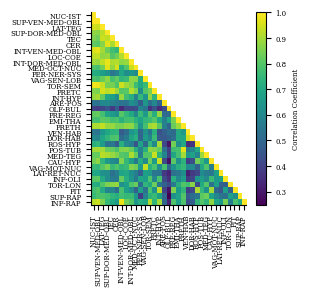

In [48]:
# vmin, vmax = -3, 3
nrows = 1
ncols = 1
cmap = 'viridis'
x_tick_steps = 1
y_tick_steps = 1
# top, bottom = 10, -1
figsize=(2.5,2.5)
change_font(font_size=5)

mask = np.triu(np.ones_like(corr_matrix_avg, dtype=bool), k=1)  # k=1 excludes above diagonal
corr_masked = np.ma.masked_where(mask, corr_matrix_avg)

fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
# a = axs.imshow(random_z_data, vmax=vmax, vmin =vmin, interpolation='none', aspect='auto', cmap='bwr')
a = axs.imshow(corr_masked, interpolation='none', aspect='auto', cmap=cmap)

axs.set_xticks(np.arange(start=0, stop=corr_matrix_avg.shape[1], step=1), abbrev_names, rotation=90)
axs.set_yticks(np.arange(start=0, stop=corr_matrix_avg.shape[0], step=1), abbrev_names)
# axs.set_ylabel('Cell ID')
axs.spines[['top', 'right']].set_visible(False)
# axs.set_title('Default matrix'.format(n_choices))
fig.colorbar(mappable=a, label='Correlation Coefficient')  
plt.savefig(os.path.join(to_save_figs_dir, 'average_{0}_corr_matrix_{1}_to_{2}.svg'.format(fish_label, 600, 1919)), dpi=600)

In [68]:
correlation_threshold = .85
adjacency_matrix = np.zeros((corr_matrix_avg.shape[0], corr_matrix_avg.shape[1]))

for Aidx, regionIDA in enumerate(regions_names_tif):
    for Bidx, regionIDB in enumerate(regions_names_tif):
        
        corr_value_AB = corr_matrix_avg[Aidx, Bidx]
                    
        if (corr_value_AB >= correlation_threshold) & (regionIDA != regionIDB):
            adjacency_matrix[Aidx, Bidx] = corr_value_AB

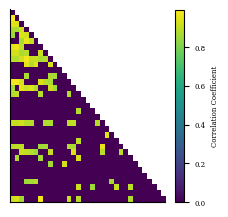

In [69]:
# vmin, vmax = -3, 3
nrows = 1
ncols = 1
cmap = 'viridis'
x_tick_steps = 1
y_tick_steps = 1
# top, bottom = 10, -1
figsize=(2.5,2.5)
change_font(font_size=5)

mask = np.triu(np.ones_like(adjacency_matrix, dtype=bool), k=1)  # k=1 excludes above diagonal
corr_masked = np.ma.masked_where(mask, adjacency_matrix)

fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
# a = axs.imshow(random_z_data, vmax=vmax, vmin =vmin, interpolation='none', aspect='auto', cmap='bwr')
a = axs.imshow(corr_masked, interpolation='none', aspect='auto', cmap=cmap)

axs.set_xticks(np.arange(start=0, stop=adjacency_matrix.shape[1], step=1), abbrev_names, rotation=90)
axs.set_yticks(np.arange(start=0, stop=adjacency_matrix.shape[0], step=1), abbrev_names)

axs.set_xticks([])
axs.set_yticks([])
# axs.set_ylabel('Cell ID')
axs.spines[['top', 'right']].set_visible(False)
# axs.grid(color='white')
# axs.set_title('Undirected, Weighted, Adjacency Matrix | {0} Threshold'.format(n_choices, correlation_threshold))
fig.colorbar(mappable=a, label='Correlation Coefficient')  
plt.savefig(os.path.join(to_save_figs_dir, 'average_{0}_corr_matrix_{1}_to_{2}_binarized.svg'.format(fish_label, 600, 1919)), dpi=600)

In [70]:
# for now not going to threshold or anything, I do not know if deleting edges is just simply settting the correlation as zero?
graph = nx.from_numpy_array(A=adjacency_matrix)

In [71]:
graph.edges()

EdgeView([(0, 1), (0, 2), (0, 3), (0, 4), (0, 6), (0, 7), (0, 8), (0, 12), (0, 13), (0, 14), (0, 19), (0, 23), (0, 32), (1, 2), (1, 3), (1, 6), (1, 7), (1, 8), (1, 12), (1, 14), (1, 19), (1, 23), (1, 25), (1, 32), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (2, 8), (2, 12), (2, 13), (2, 19), (2, 23), (2, 24), (2, 32), (3, 4), (3, 5), (3, 7), (3, 8), (3, 9), (3, 11), (3, 13), (3, 19), (3, 24), (3, 29), (4, 5), (4, 8), (4, 9), (4, 13), (4, 19), (4, 24), (4, 29), (5, 8), (5, 9), (5, 13), (5, 24), (5, 29), (6, 7), (6, 8), (6, 12), (6, 14), (6, 23), (6, 25), (6, 32), (7, 8), (7, 12), (7, 19), (7, 23), (8, 9), (8, 11), (8, 12), (8, 13), (8, 19), (8, 24), (8, 26), (9, 11), (9, 13), (11, 26), (12, 14), (12, 19), (12, 23), (12, 32), (13, 19), (13, 23), (13, 24), (14, 17), (14, 22), (14, 25), (14, 30), (14, 32), (17, 30), (18, 19), (19, 23), (19, 24), (20, 21), (21, 29), (22, 30), (23, 24), (25, 30), (25, 32)])

In [72]:
regions_names_clean

['nucleus isthmi',
 'superior ventral medulla oblongata (entire)',
 'lateral tegmentum',
 'superior dorsal medulla oblongata',
 'tectum',
 'cerebellum',
 'intermediate ventral medulla oblongata (entire)',
 'locus coeruleus',
 'intermediate dorsal medulla oblongata',
 'medial octavolateralis nucleus',
 'peripheral nervous system',
 'vagal sensory lobe',
 'torus semicircularis',
 'pretectum',
 'intermediate hypothalamus (entire)',
 'area postrema',
 'olfactory bulb',
 'preoptic region',
 'eminentia thalami',
 'prethalamus (ventral thalamus)',
 'ventral habenula',
 'dorsal habenula',
 'rostral hypothalamus',
 'posterior tuberculum (basal part of prethalamus and thalamus)',
 'medial tegmentum (entire)',
 'caudal hypothalamus',
 'vagus motor nucleus',
 'lateral reticular nucleus',
 'inferior olive',
 'torus longitudinalis',
 'pituitary',
 'superior raphe',
 'inferior raphe']

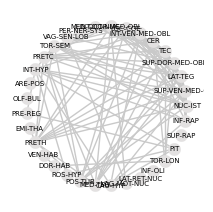

In [102]:
# vmin, vmax = -3, 3
nrows = 1
ncols = 1
cmap = 'viridis'
x_tick_steps = 1
y_tick_steps = 1
# top, bottom = 10, -1
figsize=(2.5,2.5)
change_font(font_size=5)


colorz = ['red', 'orange', 'yellow', 'green', 'blue', 'purple', 'pink', 'brown', 'black', 'grey']
linewidthz = [.1, .2, .3, .4, .5, .6, .7, .8, .9, 1.0]
labelz_graph = {}

for regionidx, regionName in enumerate(abbrev_names):
    labelz_graph[regionidx] = regionName

fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
nx.draw(graph, pos=nx.circular_layout(graph), labels=labelz_graph, font_color='black', font_size=5, node_color='#e3e1e1', node_size=10, edge_color='#c9c9c9', linewidths=6)
plt.draw()
plt.savefig(os.path.join(to_save_figs_dir, 'graph_{0}_threshold_{1}.svg'.format(fish_label, correlation_threshold)), dpi=600)

Editing the graph so it removes edges below a threshold and nodes with edges that point to itself. I am also creating a dictionary of each node and populating it with relevant information to arrive at graph metrics  

In [19]:
def add_edge(graph, vertex_i_and_j, edge_weight):
    '''
    INPUT
    graph = dict type, holds neighbors, triplets, region, and other values for each vertex in the graph 
    vertex_i_and_j = tuple type, indicates the vertex indices to add an edge too. Following proper math notation on the variables
    edge_weight = 
    
    RETURNS 
    None, just doing edits to the graph 
    Edits made is I append a tuple with the (neighbor_vertex_j, edge_i_j_weight)
    
    I am adding an edge to two values in the inputted tuple
    '''
    vertex_i, vertex_j = vertex_i_and_j[0], vertex_i_and_j[1]
    vertex_i_neighbors = graph[vertex_i]['neighbors']
    
    assert vertex_j not in vertex_i_neighbors, 'vertex j is in the neighborhood of vertex i!'
    
    graph[vertex_i]['neighbors'].append((vertex_j, edge_weight))
    # graph[vertex_j]['neighbors'].append(vertex_i)


graph_dict = {}

for vertexID, regionName in enumerate(regions_names_clean): #NOTE: Always make sure that the regions_names is uniform with regions ordering in other plots. Otherwise this is will also not match the sorting. The 'regions' key will help track 
    graph_dict[vertexID] = {'region': regionName, 'neighbors': [], 'triplets':[]}
    vertex_js = adjacency_matrix[vertexID]
    # print(regionName)
    # print('a ', vertex_js)
    for vertex_js_idx, vertex_js_weight in enumerate(vertex_js):
        # print(graph_dict[vertexID]['neighbors'])
        # print(vertex_js_idx)
        # print(graph_dict[vertex_js_idx]['neighbors'])
        vertex_i_neighbors = graph_dict[vertexID]['neighbors']
        # vertex_j_neighbors = graph_dict[vertex_js_idx]['neighbors']
        if (vertex_js_idx not in vertex_i_neighbors) & (vertex_js_weight != 0):
            add_edge(graph_dict, (vertexID, vertex_js_idx), vertex_js_weight)

    # print('vertexID {0} | Neighbors {1}'.format(vertexID, graph_dict[vertexID]['neighbors']))

### Generating metrics from graphs 

Going to save them into a dictionary for each node, so that that way I can have some way of understanding the properties of each node


**Neighborhood**

$$
N_{i} = \{ v_{j}: e_{ij} \in E \ \rm{or} \ e_{ji} \in E \}
$$

Where:
* $N_i$ is the neighbords of vertex i $v_i$
* $e_{ij}, e_{ji}$ represents the edge between two vertices $i$ and $j$
* $E$ is the set of all edges
* $v_j$ is the vertex connected to vertex i $v_i$

And so, 

We define $k_i$ as $\lvert{N_i}\rvert$, the number of vertices in $N_{i}$, the neighborhood of vertex $v_{i}$ 

#### Number of neighbors, otherwise known as degree $k_i$

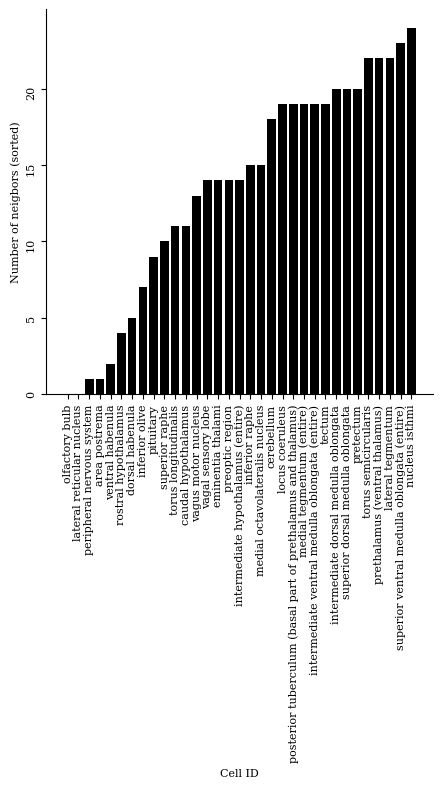

In [20]:
n_neighbors = []

for nodeID in graph_dict.keys():
    n_neighbors.append(len(graph_dict[nodeID]['neighbors']))

sorted_idx = np.argsort(np.array(n_neighbors))
sorted_idx_int = [int(sortidx) for sortidx in sorted_idx]
regions_names_clean_sorted = [regions_names_clean[sortidx] for sortidx in sorted_idx_int]

nrows = 1
ncols = 1
cmap = 'bwr'
x_tick_steps = 1
y_tick_steps = 1
# top, bottom = 10, -1
figsize=(5,5)
change_font(font_size=8)


fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
# a = axs.imshow(random_z_data, vmax=vmax, vmin =vmin, interpolation='none', aspect='auto', cmap='bwr')
a = axs.bar(range(len(n_neighbors)), np.array(n_neighbors)[sorted_idx], color='black')

axs.set_xticks(np.arange(start=0, stop=len(regions_names_clean), step=1), regions_names_clean_sorted, rotation=90)
axs.set_yticks(np.arange(start=0, stop=max(n_neighbors)+1, step=5), np.arange(start=0, stop=max(n_neighbors)+1, step=5), rotation=90)
axs.set_xlabel('Cell ID')
axs.set_ylabel('Number of neigbors (sorted)')
axs.spines[['top', 'right']].set_visible(False)


**Strength**

$$
s_i = \sum_{j=1}^{N}a_{ij}w_{ij}
$$

Where:
* $s_i$ = strength of a specific vertex $i$
* $a_{ij}$ = establishes if an edge exists between vertex $i$ and vertex $j$
* $w_{ij}$ = weight between vertex $i$ and vertex $j$

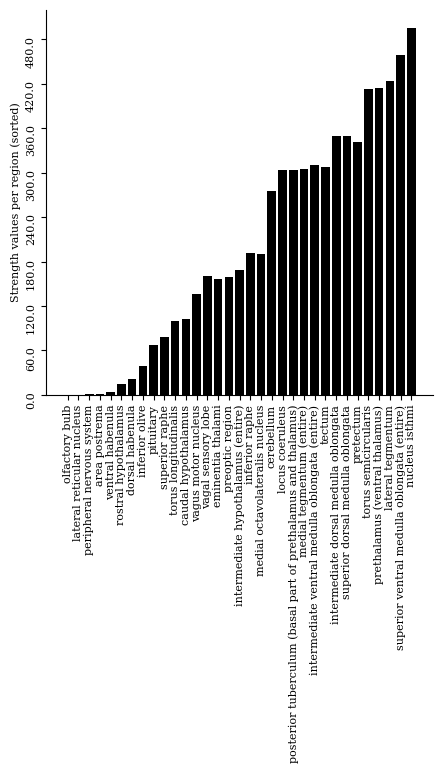

In [21]:
strength_per_vertex = []

for nodeID in graph_dict.keys():
    a_i_j = len(graph_dict[nodeID]['neighbors'])
    w_i_j = [weight_value[1] for weight_value in graph_dict[nodeID]['neighbors']]
    sum_w_i_j = np.sum(np.array(w_i_j))
    strength_value = sum_w_i_j * a_i_j
    strength_per_vertex.append(strength_value)
    

nrows = 1
ncols = 1
cmap = 'bwr'
x_tick_steps = 1
y_tick_steps = 1
# top, bottom = 10, -1
figsize=(5,5)
change_font(font_size=8)


fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
# a = axs.imshow(random_z_data, vmax=vmax, vmin =vmin, interpolation='none', aspect='auto', cmap='bwr')
a = axs.bar(range(len(strength_per_vertex)), np.array(strength_per_vertex)[sorted_idx_int], color='black')

axs.set_xticks(np.arange(start=0, stop=len(regions_names_clean), step=1), regions_names_clean_sorted, rotation=90)
axs.set_yticks(np.arange(start=0, stop=np.max(np.array(strength_per_vertex)), step=60), np.arange(start=0, stop=np.max(np.array(strength_per_vertex)), step=60), rotation=90)
# axs.set_xlabel('Cell ID')
axs.set_ylabel('Strength values per region (sorted)')
axs.spines[['top', 'right']].set_visible(False)


##### Global strength score

In [22]:
global_strength = np.sum(np.array(strength_per_vertex)) / len(strength_per_vertex)
print('Global strength: ', global_strength)

Global strength:  201.2482996710748


**Local Clustering Coefficient**

"The local clustering coefficient $C_i$ for a vertex $v_i$ is then given by a proportion of the number of links between the vertices within its neighbourhood divided by the number of links that could possibly exist between them." - [wikipedia]('https://en.wikipedia.org/wiki/Clustering_coefficient')

If a vertex $v_i$ has $k_i$ neighbors, $\frac{k_i(k_i-1)}{2}$ edges could exist among vertices in its neighborhood. 

Thus, the <ins> local clustering coefficient for undirected graphs </ins> can be defined as:

$$
C_i = \frac{2\lvert\{e_{jk} : v_j, v_k \in N_i, e_{jk} \in E \} \rvert}{k_i(k_i - 1)}
$$

Where: 
* $j$ = neighboring vertex of vertex $v_i$
* $k$ = neigbboring vertex of vertex $v_j$
  Confusing notation, but
* $k_i$ is the number of neighbors of vertex $v_i$
* $N_i$ = the neighborhood of vertex $v_i$
* $E$ = the existing set of edges in the graph
* $e_{jk}$ = is the existance of an edge between vertex $v_j$ and vertex $v_k$


However - I am working with weighted, undirected graphs, and so I need to take into account the strength of the vertices. This is a first pass attempt at what I think could make sense to adapt the un-weighted version above:

$$
C_{i_{\rm{weighted}}} = \frac{2\lvert\{s_{jk} : v_j, v_k \in N_i, e_{jk} \in E \} \rvert}{k_i(k_i - 1)}
$$

Where:

* $s_{jk}$ = the strength score between vertex $j$ and $k$ - meaning $e_{jk} \times w_{jk}$

The notation is not explicit, but we are summing across all strength values for each existing triplet, and so the $C_{i_{\rm{weighted}}}$ value is rewarded for having stronger connections.

In [23]:
for vertex_i in list(graph_dict.keys()):
    vertex_i_neighbors = [int(vertex_neighbor[0]) for vertex_neighbor in graph_dict[vertex_i]['neighbors']]
    
    for vertex_j in graph_dict[vertex_i]['neighbors']:
        vertex_j_neighbors = [int(vertex_neighbor[0]) for vertex_neighbor in graph_dict[vertex_j[0]]['neighbors']]

        for vertex_k in graph_dict[vertex_j[0]]['neighbors']:
            vertex_k_neighbors = [int(vertex_neighbor[0]) for vertex_neighbor in graph_dict[vertex_k[0]]['neighbors']]
            if vertex_k[0] in vertex_i_neighbors:
                vertex_j_k_weight = vertex_k[1]
                # print(vertex_i, vertex_j[0], vertex_k[1])
                graph_dict[vertex_i]['triplets'].append((vertex_j, vertex_k, vertex_j_k_weight))

In [24]:
# example_vertex = 0

# k_i = len(graph_dict[example_vertex]['neighbors'])
# possible_edges_in_neighborhood = k_i * (k_i - 1)
# number_of_triplets = len(graph_dict[example_vertex]['triplets'])
# clustering_coefficient = (2 * number_of_triplets) / possible_edges_in_neighborhood



In [25]:
for vertex_i in list(graph_dict.keys()):
    k_i = len(graph_dict[vertex_i]['neighbors'])
    possible_edges_in_neighborhood = k_i * (k_i - 1)
    
    if possible_edges_in_neighborhood == 0:
        graph_dict[vertex_i]['cluster_coefficient'] = 0
    else:
        number_of_triplets = len(graph_dict[vertex_i]['triplets'])

        if number_of_triplets != 0:
            w_jk_triplet = [triplet_id[2] for triplet_id in graph_dict[vertex_i]['triplets']]
            sum_w_jk = np.sum(np.array(w_jk_triplet))
            cluster_coefficient = 2 * (abs(number_of_triplets * sum_w_jk))/ possible_edges_in_neighborhood
            graph_dict[vertex_i]['cluster_coefficient'] = cluster_coefficient
        
        else:
            graph_dict[vertex_i]['cluster_coefficient'] = 0



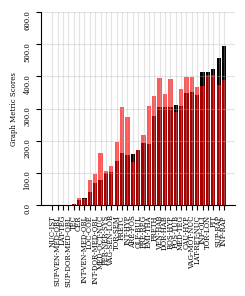

In [101]:
cluster_coefficientz = []

for nodeID in graph_dict.keys():
    cluster_coefficientz.append(graph_dict[nodeID]['cluster_coefficient'])

nrows = 1
ncols = 1
cmap = 'bwr'
x_tick_steps = 10
y_tick_steps = 100
# top, bottom = 10, -1
figsize=(2.5,2.5)
change_font(font_size=5)


fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
axs.grid(visible=True, alpha=.35)
# a = axs.imshow(random_z_data, vmax=vmax, vmin =vmin, interpolation='none', aspect='auto', cmap='bwr')
a = axs.bar(range(len(strength_per_vertex)), np.array(strength_per_vertex)[sorted_idx_int], color='black')
axs.bar(range(len(cluster_coefficientz)), np.array(cluster_coefficientz)[sorted_idx_int], color='red', alpha=.65)

axs.set_xticks(np.arange(start=0, stop=len(regions_names_clean), step=1), abbrev_names, rotation=90)
axs.set_yticks(np.arange(start=0, stop=max(cluster_coefficientz)+200, step=y_tick_steps), np.arange(start=0, stop=max(cluster_coefficientz)+200, step=y_tick_steps), rotation=90)
axs.set_ylabel('Graph Metric Scores')
# axs.set_title('Clustering coefficients for {0} randomly sampled cells'.format(n_choices))
axs.set_ylim(ymax=600, ymin=0)
axs.spines[['top', 'right']].set_visible(False)
plt.savefig(os.path.join(to_save_figs_dir, 'graph_{0}_strength_clustering.svg'.format(fish_label)), dpi=600)

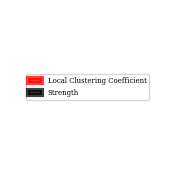

In [105]:
fig, ax = plt.subplots(figsize=(2, 2))

change_font(font_size=5)
event_colorz= ['red', 'black']
event_labelz = ['Local Clustering Coefficient', 'Strength']
# Create dummy handles for your legend entries
handles = [
    mpl.patches.Patch(color=event_colorz[idx], label=event_labelz[idx], linestyle='solid', alpha=.75, linewidth=3)
    for idx in range(len(event_colorz))
]

ax.legend(handles=handles, loc='center')
ax.axis('off')  # hide the empty axes

# plt.tight_layout()
plt.savefig(os.path.join(to_save_figs_dir, 'graph_legend.svg'), dpi=600)

##### Global clustering coefficient 

arithmetic mean of each nodes' clustering coefficient

In [28]:
global_clustering_coefficient = np.mean(cluster_coefficientz)
print('Global clustering coefficient: {0}'.format(global_clustering_coefficient))

Global clustering coefficient: 224.96144739144097


### Observing the spread of the points | strength vs. correlation coefficient

In [29]:
print(list(graph_dict.keys()))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]


(0.0, 600.0)

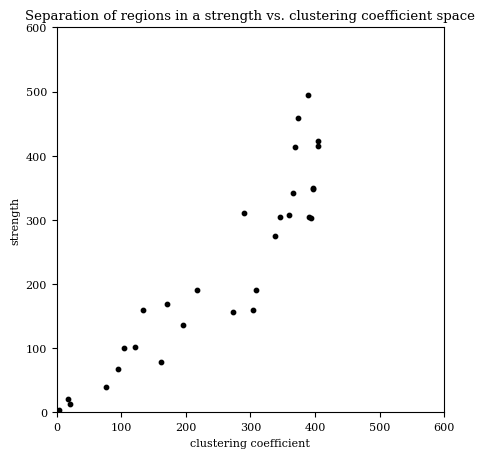

In [30]:
nrows = 1
ncols = 1
cmap = 'bwr'
x_tick_steps = 10
y_tick_steps = 200
# top, bottom = 10, -1
figsize=(5,5)
change_font(font_size=8)


fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
# a = axs.imshow(random_z_data, vmax=vmax, vmin =vmin, interpolation='none', aspect='auto', cmap='bwr')
axs.scatter(cluster_coefficientz, strength_per_vertex, s=10, color='black')
axs.set_title('Separation of regions in a strength vs. clustering coefficient space')
# axs.p

axs.set_ylabel('strength')
axs.set_xlabel('clustering coefficient')

axs.set_ylim(ymax=600, ymin=0)
axs.set_xlim(xmax=600, xmin=0)
# axs.set_yticks(np.arange(start=0, stop=max(cluster_coefficientz)+1, step=y_tick_steps), np.arange(start=0, stop=max(cluster_coefficientz)+1, step=y_tick_steps), rotation=90)
# # axs.set_ylabel('Local clustering coefficients')
# # axs.set_title('Clustering coefficients for {0} randomly sampled cells'.format(n_choices))
# axs.spines[['top', 'right']].set_visible(False)


### Assigning labels to the brain regions 

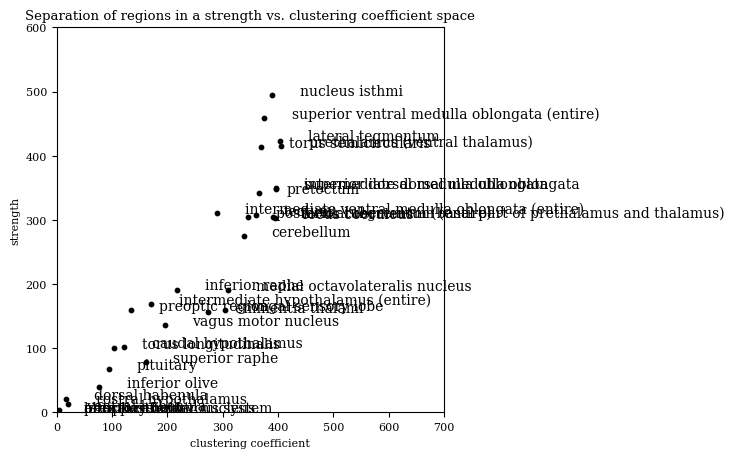

In [31]:
nrows = 1
ncols = 1
cmap = 'bwr'
x_tick_steps = 10
y_tick_steps = 200
# top, bottom = 10, -1
figsize=(5,5)
change_font(font_size=8)

#text params 
fontsize=10
fontweight=2
x_text_buffer = 50

fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
# a = axs.imshow(random_z_data, vmax=vmax, vmin =vmin, interpolation='none', aspect='auto', cmap='bwr')
axs.scatter(cluster_coefficientz, strength_per_vertex, s=10, color='black')
axs.set_title('Separation of regions in a strength vs. clustering coefficient space')
# axs.p

axs.set_ylabel('strength')
axs.set_xlabel('clustering coefficient')

axs.set_ylim(ymax=600, ymin=0)
axs.set_xlim(xmax=700, xmin=0)

for y_axis_idx, region_label_idx in enumerate(sorted_idx_int):
    axs.text(x=cluster_coefficientz[region_label_idx] + x_text_buffer, y=strength_per_vertex[region_label_idx], s = graph_dict[region_label_idx]['region'], fontsize=10, fontweight=2)
# axs.set_yticks(np.arange(start=0, stop=max(cluster_coefficientz)+1, step=y_tick_steps), np.arange(start=0, stop=max(cluster_coefficientz)+1, step=y_tick_steps), rotation=90)
# # axs.set_ylabel('Local clustering coefficients')
# # axs.set_title('Clustering coefficients for {0} randomly sampled cells'.format(n_choices))
# axs.spines[['top', 'right']].set_visible(False)


Nicknames to the brain regions, so it is easier to plot on graphs

In [32]:
# ------- FUNCTION -------
def abbreviate_and_join_list(name_list, n_letters_to_abbr):
    '''
    name_list: resulting list when you do .split on a list 
    n_letters_to_abbr: how many letters to abbreviate
    '''
    abbreviated_name = [component[:n_letters_to_abbr].upper() for component in name_list]
    joined_abbreviated_name = '_'.join(abbreviated_name)
    return joined_abbreviated_name


# ------- PARAMS -------
number_of_letters_to_abbreviate = 3 

# ------- ABBREVIATE EACH REGION -------
for region_idx, region_label_idx in enumerate(sorted_idx_int):
    # print(graph_dict[region_label_idx]['region'])
    region_label_name = graph_dict[region_label_idx]['region']
    print('\n\n', region_label_name)

    split_name = region_label_name.split(' ')

    if ' ' in region_label_name:
        
        if '(' in region_label_name:
            start_parenth_bool = False
            index_with_starting_parenthesis = 0 #start at zero and then count up
            
            while start_parenth_bool == False:
                # print(split_name[index_with_starting_parenthesis])
                if '(' in split_name[index_with_starting_parenthesis]:
                    # print('starting parenthesis in: ', split_name[index_with_starting_parenthesis])
                    start_parenth_bool = True
                    
                index_with_starting_parenthesis += 1 

            # print(split_name[:index_with_starting_parenthesis-1])
            non_parenthesis_split_name = split_name[:index_with_starting_parenthesis-1]
            abbr_and_join_name = abbreviate_and_join_list(non_parenthesis_split_name, number_of_letters_to_abbreviate)
            print(abbr_and_join_name)
        
        else:
            abbr_and_join_name = abbreviate_and_join_list(split_name, number_of_letters_to_abbreviate)
            print(abbr_and_join_name)
        
    else:
        abbr_and_join_name = abbreviate_and_join_list(split_name, number_of_letters_to_abbreviate)
        print(abbr_and_join_name)

    # Assign the abbreviation to the region in the graph_dict
    graph_dict[region_label_idx]['abbreviation'] = abbr_and_join_name



 olfactory bulb
OLF_BUL


 lateral reticular nucleus
LAT_RET_NUC


 peripheral nervous system
PER_NER_SYS


 area postrema
ARE_POS


 ventral habenula
VEN_HAB


 rostral hypothalamus
ROS_HYP


 dorsal habenula
DOR_HAB


 inferior olive
INF_OLI


 pituitary
PIT


 superior raphe
SUP_RAP


 torus longitudinalis
TOR_LON


 caudal hypothalamus
CAU_HYP


 vagus motor nucleus
VAG_MOT_NUC


 vagal sensory lobe
VAG_SEN_LOB


 eminentia thalami
EMI_THA


 preoptic region
PRE_REG


 intermediate hypothalamus (entire)
INT_HYP


 inferior raphe
INF_RAP


 medial octavolateralis nucleus
MED_OCT_NUC


 cerebellum
CER


 locus coeruleus
LOC_COE


 posterior tuberculum (basal part of prethalamus and thalamus)
POS_TUB


 medial tegmentum (entire)
MED_TEG


 intermediate ventral medulla oblongata (entire)
INT_VEN_MED_OBL


 tectum
TEC


 intermediate dorsal medulla oblongata
INT_DOR_MED_OBL


 superior dorsal medulla oblongata
SUP_DOR_MED_OBL


 pretectum
PRE


 torus semicircularis
TOR_SEM


 prethal

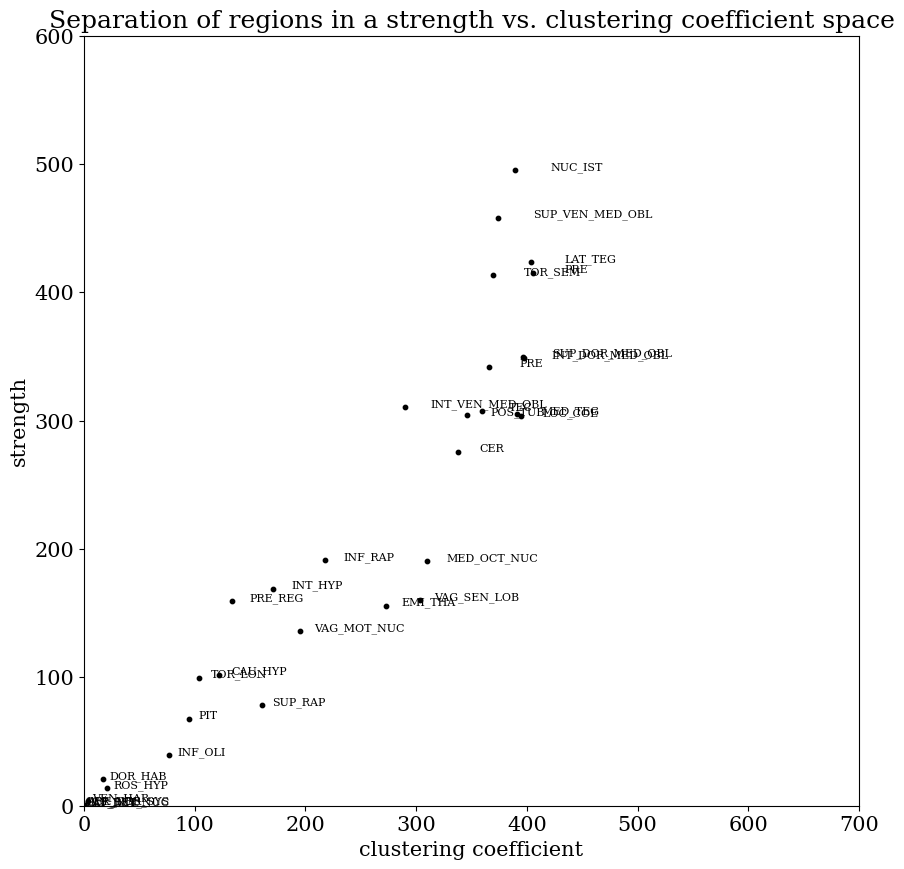

In [33]:
nrows = 1
ncols = 1
cmap = 'bwr'
x_tick_steps = 10
y_tick_steps = 200
# top, bottom = 10, -1
figsize=(10,10)
change_font(font_size=15)

#text params 
fontsize=8
fontweight=2
x_text_buffer = 1
y_text_buffer = .5

fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
# a = axs.imshow(random_z_data, vmax=vmax, vmin =vmin, interpolation='none', aspect='auto', cmap='bwr')
axs.scatter(cluster_coefficientz, strength_per_vertex, s=10, color='black')
axs.set_title('Separation of regions in a strength vs. clustering coefficient space')
# axs.p

axs.set_ylabel('strength')
axs.set_xlabel('clustering coefficient')

axs.set_ylim(ymax=600, ymin=0)
axs.set_xlim(xmax=700, xmin=0)

for y_axis_idx, region_label_idx in enumerate(sorted_idx_int):
    axs.text(x=cluster_coefficientz[region_label_idx] + (x_text_buffer*y_axis_idx), y=strength_per_vertex[region_label_idx]+ y_text_buffer, s = graph_dict[region_label_idx]['abbreviation'], fontsize=fontsize, fontweight=fontweight)
# axs.set_yticks(np.arange(start=0, stop=max(cluster_coefficientz)+1, step=y_tick_steps), np.arange(start=0, stop=max(cluster_coefficientz)+1, step=y_tick_steps), rotation=90)
# # axs.set_ylabel('Local clustering coefficients')
# # axs.set_title('Clustering coefficients for {0} randomly sampled cells'.format(n_choices))
# axs.spines[['top', 'right']].set_visible(False)


#### Saving the graph as a dictionary for comparing across samples, conditions

In [34]:
fish_label = '20250326_fish2'
graph_dict_fname = os.path.join(fish_dir, 'corr_matrices', 'graph_dict_{0}.pkl'.format(fish_label))

with open(graph_dict_fname, 'wb') as f:
    pickle.dump(graph_dict, f)
    f.close()